# CMS Open Data Usage — Cleanup & Analysis

Loads the CSV produced by `paper_extractor.py`, cleans it, writes a cleaned CSV, prints summary tables, and shows plots inline.

In [1]:
# --- Config: set this to your CSV path ---
INPUT_CSV = "cms_open_data_usage.csv"

In [9]:
INPUT_CSV = r"C:\Users\ejren\OneDrive\CMS_DPOA\CMS_DPOA_text_extraction\cms_open_data_usage.csv"

In [10]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Cleanup helpers

In [11]:
def normalize_dataset_key(name: str) -> str:
    """Collapse casing/punctuation so the same MC sample across papers groups together."""
    if not isinstance(name, str) or not name.strip():
        return ""
    s = name.lower().strip()
    s = re.sub(r"[\s\-_/]+", "_", s)
    s = re.sub(r"[^\w]", "", s)
    return s


def parse_luminosity_pb(lumi: str) -> float:
    """Parse strings like '31.8/pb', '11.6/fb', '2.3 fb-1' into pb^-1 as a float."""
    if not isinstance(lumi, str) or not lumi.strip():
        return float("nan")
    s = lumi.lower().replace(" ", "").replace("^-1", "").replace("-1", "")
    m = re.search(r"([0-9]*\.?[0-9]+)\s*/?\s*(pb|fb|ab|nb)", s)
    if not m:
        return float("nan")
    value = float(m.group(1))
    unit = m.group(2)
    multipliers = {"nb": 1e-3, "pb": 1.0, "fb": 1e3, "ab": 1e6}
    return value * multipliers[unit]


def flag_suspicious_events(row) -> str:
    """Catch known extraction errors in events_used / events_total."""
    flags = []
    notes = str(row.get("notes", "") or "")
    used = row.get("events_used_num")
    total = row.get("events_total_num")

    if pd.notna(used):
        xs_match = re.search(r"cross[\s-]?section[^\d]*([\d.]+)\s*pb", notes, re.IGNORECASE)
        if xs_match:
            try:
                xs_val = float(xs_match.group(1))
                if abs(xs_val - used) / max(used, 1) < 0.01:
                    flags.append("events_used==cross_section")
            except ValueError:
                pass
        if "weighted events" in notes.lower():
            flags.append("weighted_not_raw")

    if pd.notna(used) and pd.notna(total) and used > total:
        flags.append("used>total")

    return ";".join(flags)

## 2. Load and clean

In [12]:
df = pd.read_csv(INPUT_CSV)
print(f"Loaded {len(df)} rows from {INPUT_CSV}")

# Numeric conversions
df["events_total_num"] = pd.to_numeric(df["events_total (from text)"], errors="coerce")
df["events_used_num"] = pd.to_numeric(df["events_used (from text)"], errors="coerce")
df["collision_energy_tev_num"] = pd.to_numeric(df["collision_energy_tev"], errors="coerce")

# Luminosity in pb^-1
df["luminosity_pb"] = df["luminosity"].apply(parse_luminosity_pb)

# Normalized dataset key for cross-paper grouping
df["dataset_key"] = df["dataset_name"].apply(normalize_dataset_key)

# Clean dataset_type
df["dataset_type"] = df["dataset_type"].astype(str).str.strip().str.lower()
df.loc[~df["dataset_type"].isin(["data", "mc", "derived"]), "dataset_type"] = ""

# Fraction of dataset used
df["fraction_used"] = df["events_used_num"] / df["events_total_num"]
df.loc[df["fraction_used"] > 1, "fraction_used"] = float("nan")

# Has official path
df["has_official_path"] = df["official_path"].astype(str).str.strip().ne("")

# Normalize pdf_path slashes
df["pdf_path"] = df["pdf_path"].astype(str).str.replace("\\", "/", regex=False)

# Flag suspicious rows
df["quality_flags"] = df.apply(flag_suspicious_events, axis=1)

# Save cleaned CSV
out_csv = Path(INPUT_CSV).with_name(Path(INPUT_CSV).stem + "_clean.csv")
df.to_csv(out_csv, index=False)
print(f"Wrote cleaned CSV: {out_csv}")
df.head()

Loaded 107 rows from C:\Users\ejren\OneDrive\CMS_DPOA\CMS_DPOA_text_extraction\cms_open_data_usage.csv
Wrote cleaned CSV: C:\Users\ejren\OneDrive\CMS_DPOA\CMS_DPOA_text_extraction\cms_open_data_usage_clean.csv


,paper,full_paper_name,year_published,journal,authors,doi,abstract,arxiv_url,pdf_url,primary_category,...,shortened_paper_name,notes,events_total_num,events_used_num,collision_energy_tev_num,luminosity_pb,dataset_key,fraction_used,has_official_path,quality_flags
0,2403.08907,The terascale tutorial,2024,NaN,Konstantinos Theofilatos,NaN,This note summarizes the lectures given in the...,http://arxiv.org/abs/2403.08907,https://arxiv.org/pdf/2403.08907v1,hep-ex,...,Terascale Tutorial CMS Open Data,Single muon trigger events; pocket-size data s...,NaN,469384.0,7.0,50.0,cms_hep_tutorial_dataset,NaN,True,
1,2403.08907,The terascale tutorial,2024,NaN,Konstantinos Theofilatos,NaN,This note summarizes the lectures given in the...,http://arxiv.org/abs/2403.08907,https://arxiv.org/pdf/2403.08907v1,hep-ex,...,Terascale Tutorial CMS Open Data,Cross section 165 pb; weighted events: 7928.6;...,NaN,36941.0,7.0,NaN,ttbar_mc_sample,NaN,True,weighted_not_raw
2,2403.08907,The terascale tutorial,2024,NaN,Konstantinos Theofilatos,NaN,This note summarizes the lectures given in the...,http://arxiv.org/abs/2403.08907,https://arxiv.org/pdf/2403.08907v1,hep-ex,...,Terascale Tutorial CMS Open Data,Cross section 31300 pb; weighted events: 20957...,NaN,109737.0,7.0,NaN,wjets_mc_sample,NaN,True,weighted_not_raw
3,2403.08907,The terascale tutorial,2024,NaN,Konstantinos Theofilatos,NaN,This note summarizes the lectures given in the...,http://arxiv.org/abs/2403.08907,https://arxiv.org/pdf/2403.08907v1,hep-ex,...,Terascale Tutorial CMS Open Data,Cross section 15800 pb; weighted events: 34113...,NaN,77729.0,7.0,NaN,dyjets_mc_sample,NaN,True,weighted_not_raw
4,2403.08907,The terascale tutorial,2024,NaN,Konstantinos Theofilatos,NaN,This note summarizes the lectures given in the...,http://arxiv.org/abs/2403.08907,https://arxiv.org/pdf/2403.08907v1,hep-ex,...,Terascale Tutorial CMS Open Data,Cross section 4580 pb; weighted events: 229.9;...,NaN,4580.0,7.0,NaN,ww_mc_sample,NaN,True,events_used==cross_section;weighted_not_raw


## 3. Summary tables

In [13]:
n_papers = df["paper"].nunique()
n_rows = len(df)
print(f"Papers:           {n_papers}")
print(f"Dataset rows:     {n_rows}")
print(f"Avg datasets/paper: {n_rows / n_papers:.1f}")

Papers:           25
Dataset rows:     107
Avg datasets/paper: 4.3


In [14]:
print("Dataset type breakdown:")
print(df["dataset_type"].value_counts(dropna=False))

Dataset type breakdown:
dataset_type
mc      77
data    30
Name: count, dtype: int64


In [15]:
print("Papers per year:")
per_year = df.drop_duplicates("paper")["year_published"].value_counts().sort_index()
print(per_year)

Papers per year:
year_published
2017    2
2018    1
2019    7
2020    1
2021    5
2022    1
2023    5
2024    2
2025    1
Name: count, dtype: int64


In [16]:
print("Collision energy (TeV):")
print(df["collision_energy_tev_num"].value_counts(dropna=False).sort_index())

Collision energy (TeV):
collision_energy_tev_num
7.0     40
8.0     56
13.0     7
NaN      4
Name: count, dtype: int64


In [17]:
print("Top 15 most-reused datasets (by # of papers citing):")
reuse = (
    df[df["dataset_key"] != ""]
    .groupby("dataset_key")["paper"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)
print(reuse)

Top 15 most-reused datasets (by # of papers citing):
dataset_key
wwjetsto2l2nu_tunez2star_8tev                  4
dytomumu_m_20_ct10_tunez2star_v2_8tev          4
wzjetsto3lnu_8tev_tunez2star                   4
zzto4mu_8tev                                   3
dyjetstoll_tunez2_m_50_7tev_madgraph_tauola    2
ttjets_hadronicmgdecays_tunep11mpihi_8tev      2
ttjets_semileptmgdecays_8tev                   2
ttjets_fullleptmgdecays_8tev                   2
ttjets_fullleptmgdecays_tunep11tev_8tev        2
_singleelectron_run2012b_22jan2013_v1          1
cms_2012_proton_proton_data                    1
cms_2012_singlemu_dataset                      1
cms_2012_singlemu_open_data                    1
cms_2012_tt_monte_carlo                        1
cms_2012_wjets_monte_carlo                     1
Name: paper, dtype: int64


In [18]:
print("Official CMS dataset path cited?")
print(df["has_official_path"].value_counts())
print(f"Rate: {df['has_official_path'].mean():.1%}")

Official CMS dataset path cited?
has_official_path
True    107
Name: count, dtype: int64
Rate: 100.0%


In [19]:
frac = df["fraction_used"].dropna()
print(f"Fraction of dataset processed (rows with both numbers): {len(frac)}")
if len(frac):
    print(f"  median: {frac.median():.3f}")
    print(f"  mean:   {frac.mean():.3f}")
    print(f"  min:    {frac.min():.3f}")
    print(f"  max:    {frac.max():.3f}")

Fraction of dataset processed (rows with both numbers): 4
  median: 0.575
  mean:   0.547
  min:    0.038
  max:    1.000


In [20]:
lumi = df["luminosity_pb"].dropna()
print(f"Rows with luminosity: {len(lumi)}")
if len(lumi):
    print(f"  median: {lumi.median():.2f} pb^-1")
    print(f"  mean:   {lumi.mean():.2f} pb^-1")
    print(f"  range:  {lumi.min():.2f} – {lumi.max():.2f} pb^-1")

Rows with luminosity: 25
  median: 4166.00 pb^-1
  mean:   5205.66 pb^-1
  range:  31.80 – 20600.00 pb^-1


In [21]:
data_rows = df[df["dataset_type"] == "data"]
mc_rows = df[df["dataset_type"] == "mc"]
print("Total events processed across all papers:")
print(f"  real data: {data_rows['events_used_num'].sum():,.0f}")
print(f"  MC:        {mc_rows['events_used_num'].sum():,.0f}")

Total events processed across all papers:
  real data: 84,383,032
  MC:        22,477,362


In [22]:
flagged = df[df["quality_flags"] != ""]
print(f"Flagged rows needing review: {len(flagged)}")
if len(flagged):
    print(flagged["quality_flags"].value_counts())
    print()
    display(flagged[["paper", "dataset_name", "events_used_num", "quality_flags"]].head(15))

Flagged rows needing review: 8
quality_flags
weighted_not_raw                               4
events_used==cross_section;weighted_not_raw    4
Name: count, dtype: int64



,paper,dataset_name,events_used_num,quality_flags
1,2403.08907,TTbar MC sample,36941.0,weighted_not_raw
2,2403.08907,WJets MC sample,109737.0,weighted_not_raw
3,2403.08907,DYJets MC sample,77729.0,weighted_not_raw
4,2403.08907,WW MC sample,4580.0,events_used==cross_section;weighted_not_raw
5,2403.08907,WZ MC sample,3367.0,events_used==cross_section;weighted_not_raw
6,2403.08907,ZZ MC sample,2421.0,events_used==cross_section;weighted_not_raw
7,2403.08907,Single Top MC sample,5684.0,events_used==cross_section;weighted_not_raw
8,2403.08907,QCD MC sample,142.0,weighted_not_raw


## 4. Plots

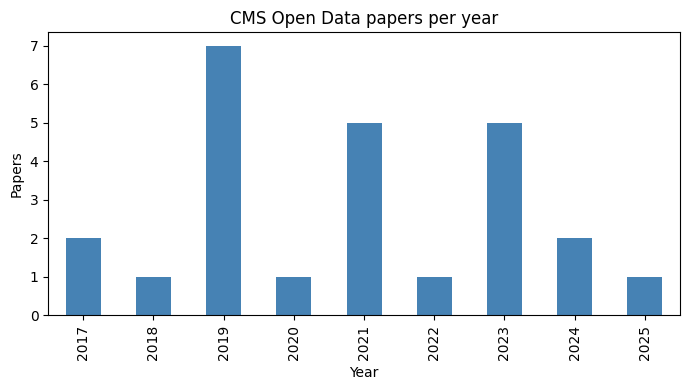

In [23]:
# Papers per year
fig, ax = plt.subplots(figsize=(7, 4))
per_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Papers")
ax.set_title("CMS Open Data papers per year")
plt.tight_layout()
plt.show()

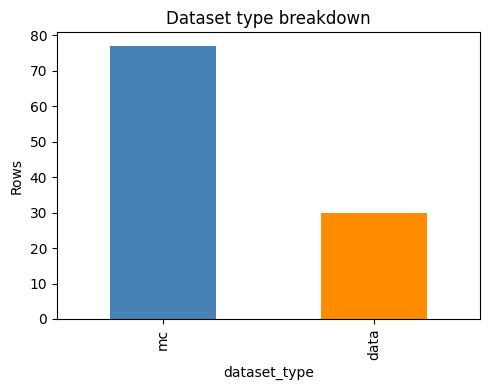

In [24]:
# Data vs MC
fig, ax = plt.subplots(figsize=(5, 4))
df["dataset_type"].replace("", "unknown").value_counts().plot(
    kind="bar", ax=ax, color=["steelblue", "darkorange", "gray", "lightgray"]
)
ax.set_ylabel("Rows")
ax.set_title("Dataset type breakdown")
plt.tight_layout()
plt.show()

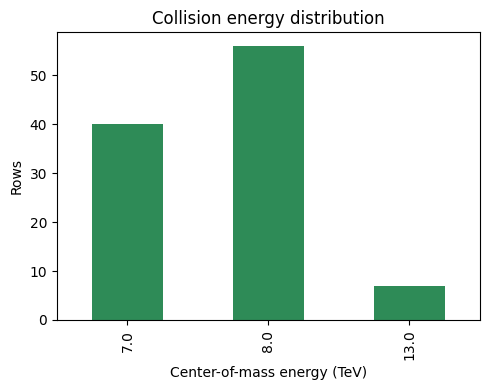

In [25]:
# Collision energy
energy = df["collision_energy_tev_num"].dropna()
if len(energy):
    fig, ax = plt.subplots(figsize=(5, 4))
    energy.value_counts().sort_index().plot(kind="bar", ax=ax, color="seagreen")
    ax.set_xlabel("Center-of-mass energy (TeV)")
    ax.set_ylabel("Rows")
    ax.set_title("Collision energy distribution")
    plt.tight_layout()
    plt.show()

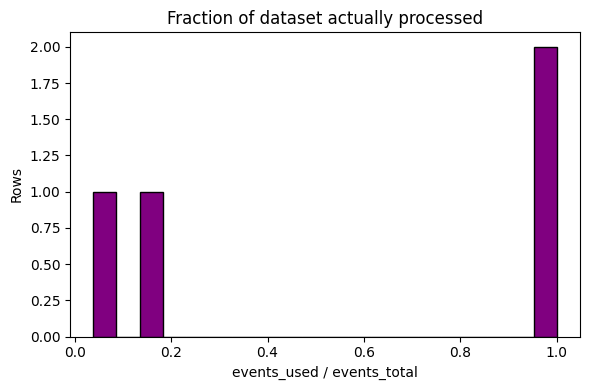

In [26]:
# Fraction used histogram
if len(frac):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(frac, bins=20, color="purple", edgecolor="black")
    ax.set_xlabel("events_used / events_total")
    ax.set_ylabel("Rows")
    ax.set_title("Fraction of dataset actually processed")
    plt.tight_layout()
    plt.show()

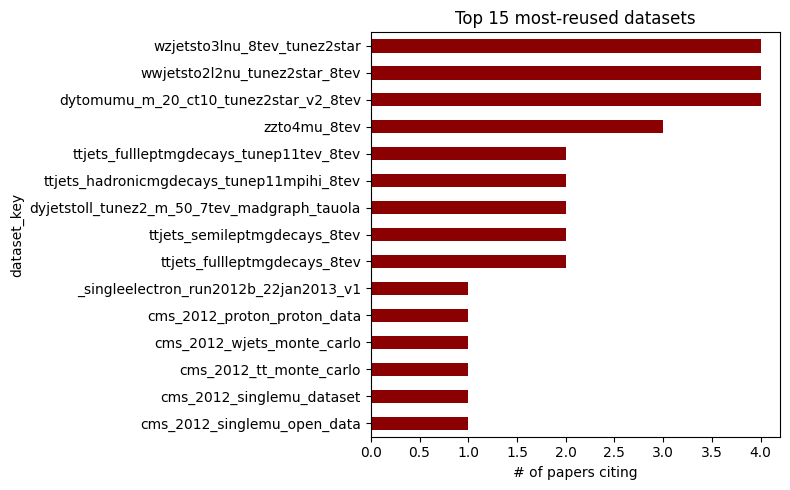

In [27]:
# Top reused datasets bar chart
if len(reuse):
    fig, ax = plt.subplots(figsize=(8, 5))
    reuse.sort_values().plot(kind="barh", ax=ax, color="darkred")
    ax.set_xlabel("# of papers citing")
    ax.set_title("Top 15 most-reused datasets")
    plt.tight_layout()
    plt.show()